# COGS 109 — Data Overview
## How Data Centers Affect Local Communities: Panel Dataset Documentation

This notebook documents the `panel_master.csv` dataset used for regression analysis of Meta data center impacts on local county-level outcomes.

**Panel:** County × Year, 2010–2022  
**States:** Ohio (OH), Virginia (VA), Nebraska (NE)  
**Unit of observation:** County-year  
**Total rows:** 4,433 | **Counties:** 341 (3 treated, 332 clean controls, 6 excluded)

---

### Study Design

This is a **difference-in-differences (DiD)** / event study. Three counties received Meta data centers between 2019–2020. All other counties in the same three states serve as controls, minus counties with their own known hyperscale data centers.

| County | FIPS | State | Meta Opening Year | Notes |
|--------|------|-------|-------------------|-------|
| Licking County | 39089 | OH | **2020** | Groundbreaking 2017; Building 1 operational Feb 2020 |
| Henrico County | 51087 | VA | **2020** | Operational Aug 2020 (Meta newsroom confirmed) |
| Sarpy County | 31153 | NE | **2019** | ⚠️ Google also opened in Sarpy County Oct 2019 — **compound treatment** |

> **Note on original brief:** Opening years were initially listed as ~2017, ~2018, and 2019. The first two were groundbreaking dates, not operational. All years verified from primary sources (Meta newsroom, Baxtel, local news).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/panel_master.csv', dtype={'fips': str})

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nYears: {df.year.min()} – {df.year.max()}')
print(f'Counties: {df.fips.nunique()} total')
print(f'  Treated:             {df[df.is_treated==1].fips.nunique()}')
print(f'  Contaminated (excl): {df[df.contaminated_control==1].fips.nunique()}')
print(f'  Clean controls:      {df[(df.is_treated==0)&(df.contaminated_control==0)].fips.nunique()}')

Shape: (4433, 25)
Columns: ['fips', 'year', 'per_capita_income', 'gdp_thousands', 'median_income', 'poverty_rate', 'pct_bachelors', 'pop_density', 'unemployment_acs', 'median_age', 'elec_rate_cents_kwh', 'residential_sales_mwh', 'residential_customers', 'total_employment', 'total_wages', 'avg_annual_wage', 'data_processing_employment', 'total_establishments', 'unemployment_rate', 'labor_force', 'is_treated', 'dc_opening_year', 'dc_active', 'years_since_dc', 'contaminated_control']

Years: 2010 – 2022
Counties: 341 total
  Treated:             3
  Contaminated (excl): 6
  Clean controls:      332


In [2]:
df.head()

,fips,year,per_capita_income,gdp_thousands,median_income,poverty_rate,pct_bachelors,pop_density,unemployment_acs,median_age,...,avg_annual_wage,data_processing_employment,total_establishments,unemployment_rate,labor_force,is_treated,dc_opening_year,dc_active,years_since_dc,contaminated_control
0,31001,2010,36869.0,1586875.0,44443.0,NaN,21.5,55.259075,5.5,37.5,...,31979.0,NaN,1029.0,4.8,16472.0,0,NaN,0,0.0,0
1,31001,2011,41094.0,1709251.0,47469.0,NaN,22.4,55.356718,5.3,37.7,...,32624.0,NaN,1026.0,4.3,16493.0,0,NaN,0,0.0,0
2,31001,2012,43050.0,1735273.0,49017.0,12.4,21.2,55.566208,5.4,37.8,...,33675.0,NaN,1171.0,3.7,16851.0,0,NaN,0,0.0,0
3,31001,2013,44098.0,1867247.0,49440.0,12.8,20.4,55.686930,6.2,38.0,...,33836.0,NaN,1199.0,3.6,16906.0,0,NaN,0,0.0,0
4,31001,2014,45637.0,1845389.0,51342.0,11.8,22.3,55.738415,6.7,38.1,...,34981.0,NaN,1197.0,3.4,16728.0,0,NaN,0,0.0,0


---
## Data Sources

Six sources were pulled in parallel by automated agents. Each raw CSV is in `data/raw/` with an accompanying `_notes.md` file.

### 1. BEA Regional Economic Accounts (`bea_panel.csv`)
- **Source:** BEA API (`apps.bea.gov/api/data`), tables CAINC1 and CAGDP1
- **Variables:** `per_capita_income` (current $), `gdp_thousands` (chained 2017 $)
- **Coverage:** 3,718 rows, **zero missing values**
- **Notes:** LineCode=3 for per-capita income, LineCode=1 for real GDP. Both tables go back to 2010 at county level.

### 2. Census ACS 5-Year Estimates (`census_acs_panel.csv`)
- **Source:** Census API (`api.census.gov`), ACS5 surveys 2010–2022
- **Variables:** `median_income`, `poverty_rate`, `pct_bachelors`, `pop_density`, `unemployment_acs`, `median_age`
- **Coverage:** 4,086 rows
- **Known gaps:**
  - `poverty_rate`: NaN for 2010–2011 (ACS subject table S1701 didn't exist those years)
  - `pct_bachelors`: Variable code changed between 2014→2015 (C01_015E → C02_015E); handled automatically
  - Bedford city VA (FIPS 51515): NaN `pop_density` for 2010–2013 (merged into Bedford County 2013)
- **Land area:** From 2020 Census Gazetteer file

### 3. EIA Form 861 (`eia861_panel.csv`)
- **Source:** EIA bulk ZIP files (`eia.gov/electricity/data/eia861/`), annual 2010–2022
- **Variables:** `elec_rate_cents_kwh` (customer-weighted avg across utilities serving each county)
- **Coverage:** 4,095 rows; 5.3% missing rate (small rural NE counties 2020–2022)
- **Important limitation:** `residential_sales_mwh` and `residential_customers` are **structurally all-NaN** — EIA 861 is utility-level data; summing statewide utility totals across counties would severely overcount. Rate column is reliable.
- **Schema note:** File structure changed 6 times between 2010–2022 (different XLS layouts, column shifts). Verified rates: NE ~10.6¢, OH ~12.5¢, VA ~11.4¢/kWh — consistent with known state averages.

### 4. BLS QCEW (`bls_qcew_panel.csv`)
- **Source:** Hybrid approach — BLS ZIP files (`data.bls.gov/cew/`) for 2010–2013, per-county API slices for 2014–2022 (ZIPs too slow on network)
- **Variables:** `total_employment`, `total_wages`, `avg_annual_wage`, `total_establishments`, `data_processing_employment` (NAICS 518+519)
- **Coverage:** 4,125 rows
- **Suppression:** BLS suppresses small cell counts (`disclosure_code='N'`); treated as NaN
- **`data_processing_employment`:** 74.5% NaN — expected; most small counties have zero or suppressed NAICS 518/519 establishments. This is the key variable for measuring data center employment spillovers.
- **Sanity check:** Loudoun County VA (world's largest data center hub) shows NAICS 518/519 employment growing from 587 (2010) → 2,226 (2022) ✓

### 5. BLS LAUS (`bls_laus_panel.csv`)
- **Source:** BLS annual county flat files — retrieved via Wayback Machine (BLS blocks direct programmatic access via Akamai CDN)
- **Variables:** `unemployment_rate`, `labor_force`
- **Coverage:** 4,082 rows, **zero missing values**
- **Notes:** Files are fixed-width (132 chars/row), contain annual averages directly (no monthly aggregation needed)

### 6. Treatment Variable (`treatment.csv`)
- **Source:** Hand-coded from Meta newsroom, Baxtel, local news — minimum 2 sources per county
- **3 rows only** — one per treated county
- **`contaminated_control`** flag added to panel for 6 counties with known hyperscale facilities (see below)

---
## Excluded Control Counties

The following counties were **not** used as controls because they have their own large data center presence, which would bias the control group.

| FIPS | County | State | Reason |
|------|--------|-------|--------|
| 39049 | Franklin | OH | Google New Albany campus ~2022; shares a border with Licking County |
| 51107 | Loudoun | VA | AWS/Google/Microsoft — world's densest data center concentration |
| 51153 | Prince William | VA | AWS Manassas campus |
| 51059 | Fairfax | VA | AWS/Microsoft presence |
| 51117 | Mecklenburg | VA | Microsoft Boydton campus, operational ~2011 |
| 31055 | Douglas | NE | Google announced ~2022 |

These are flagged in `panel_master.csv` via `contaminated_control == 1`. Drop them before running regressions:
```python
clean = df[(df.contaminated_control == 0)]
```

In [3]:
# Missing data summary
miss = df.isna().sum()
miss = miss[miss > 0].to_frame('n_missing')
miss['pct'] = (miss.n_missing / len(df) * 100).round(1)
miss['note'] = {
    'per_capita_income': 'BEA: mismatched FIPS across merge (extra rows from outer join)',
    'gdp_thousands': 'BEA: same as above',
    'median_income': 'ACS: outer join artifact',
    'poverty_rate': 'ACS: S1701 variable not available 2010–2011',
    'pct_bachelors': 'ACS: outer join artifact',
    'pop_density': 'ACS: outer join artifact + Bedford city VA',
    'unemployment_acs': 'ACS: outer join artifact',
    'median_age': 'ACS: outer join artifact',
    'elec_rate_cents_kwh': 'EIA: small rural NE counties 2020–2022 dropped from utility territory files',
    'residential_sales_mwh': 'EIA: STRUCTURAL — utility data cannot be allocated to counties without double-counting',
    'residential_customers': 'EIA: STRUCTURAL — same reason',
    'total_employment': 'QCEW: outer join artifact',
    'total_wages': 'QCEW: outer join artifact',
    'avg_annual_wage': 'QCEW: outer join artifact',
    'data_processing_employment': 'QCEW: most small counties have zero or suppressed NAICS 518/519 — expected',
    'total_establishments': 'QCEW: outer join artifact',
    'unemployment_rate': 'LAUS: outer join artifact',
    'labor_force': 'LAUS: outer join artifact',
    'dc_opening_year': 'Only set for 3 treated counties by design',
}.get
miss['note'] = miss.index.map(lambda c: {
    'per_capita_income': 'BEA outer join artifact',
    'gdp_thousands': 'BEA outer join artifact',
    'median_income': 'ACS outer join artifact',
    'poverty_rate': 'ACS S1701 not available 2010–2011 for any county',
    'pct_bachelors': 'ACS outer join artifact',
    'pop_density': 'ACS outer join artifact + Bedford city VA (FIPS 51515)',
    'unemployment_acs': 'ACS outer join artifact',
    'median_age': 'ACS outer join artifact',
    'elec_rate_cents_kwh': 'Small rural NE counties missing from EIA territory files 2020–2022',
    'residential_sales_mwh': '⛔ STRUCTURAL — drop this column',
    'residential_customers': '⛔ STRUCTURAL — drop this column',
    'total_employment': 'QCEW outer join artifact',
    'total_wages': 'QCEW outer join artifact',
    'avg_annual_wage': 'QCEW outer join artifact',
    'data_processing_employment': 'Expected — most counties have no NAICS 518/519 or suppressed cells',
    'total_establishments': 'QCEW outer join artifact',
    'unemployment_rate': 'LAUS outer join artifact',
    'labor_force': 'LAUS outer join artifact',
    'dc_opening_year': 'By design — only set for 3 treated counties',
}.get(c, ''))

print(miss.to_string())

                            n_missing    pct                                                                note
per_capita_income                 715   16.1                                             BEA outer join artifact
gdp_thousands                     715   16.1                                             BEA outer join artifact
median_income                     347    7.8                                             ACS outer join artifact
poverty_rate                      977   22.0                    ACS S1701 not available 2010–2011 for any county
pct_bachelors                     347    7.8                                             ACS outer join artifact
pop_density                       351    7.9              ACS outer join artifact + Bedford city VA (FIPS 51515)
unemployment_acs                  347    7.8                                             ACS outer join artifact
median_age                        347    7.8                                             ACS out

---
## Variable Reference

| Column | Source | Units | Notes |
|--------|--------|-------|-------|
| `fips` | — | string | 5-char zero-padded county FIPS |
| `year` | — | int | 2010–2022 |
| `per_capita_income` | BEA CAINC1 | current $ | LineCode=3 |
| `gdp_thousands` | BEA CAGDP1 | thousands, chained 2017 $ | LineCode=1; **log-transform before use** |
| `median_income` | ACS B19013 | current $ | |
| `poverty_rate` | ACS S1701 | % | NaN for 2010–2011 |
| `pct_bachelors` | ACS S1501 | % of 25+ adults | Variable code changed 2014→2015; handled |
| `pop_density` | ACS B01003 + Gazetteer | persons/sq mi | **log-transform before use** |
| `unemployment_acs` | ACS S2301 | % | |
| `median_age` | ACS B01002 | years | |
| `elec_rate_cents_kwh` | EIA Form 861 | ¢/kWh | Customer-weighted avg across utilities |
| `residential_sales_mwh` | EIA Form 861 | MWh | ⛔ 100% NaN — drop |
| `residential_customers` | EIA Form 861 | count | ⛔ 100% NaN — drop |
| `total_employment` | BLS QCEW | persons | Annual avg; all ownerships, all industries |
| `total_wages` | BLS QCEW | $ | Annual total |
| `avg_annual_wage` | BLS QCEW | $/year | |
| `total_establishments` | BLS QCEW | count | Annual avg |
| `data_processing_employment` | BLS QCEW | persons | NAICS 518+519; 74.5% NaN (small counties) |
| `unemployment_rate` | BLS LAUS | % | Annual average |
| `labor_force` | BLS LAUS | persons | Annual average; **log-transform before use** |
| `is_treated` | Treatment | 0/1 | 1 for Licking/Henrico/Sarpy |
| `dc_opening_year` | Treatment | year | NaN for control counties |
| `dc_active` | Derived | 0/1 | 1 if treated county & year ≥ opening year |
| `years_since_dc` | Derived | int | 0 for controls; years post-opening for treated |
| `contaminated_control` | Treatment | 0/1 | 1 = has own data center — exclude from controls |

In [4]:
# Summary statistics — clean panel only
clean = df[(df.contaminated_control == 0)]
drop_cols = ['residential_sales_mwh', 'residential_customers', 'dc_opening_year',
             'is_treated', 'dc_active', 'years_since_dc', 'contaminated_control']
numeric_cols = [c for c in clean.select_dtypes(include='number').columns if c not in drop_cols + ['year']]

print('Summary statistics (clean panel: treated + clean controls, excl. structural NaN columns)')
print('='*80)
clean[numeric_cols].describe().round(2)

Summary statistics (clean panel: treated + clean controls, excl. structural NaN columns)


,per_capita_income,gdp_thousands,median_income,poverty_rate,pct_bachelors,pop_density,unemployment_acs,median_age,elec_rate_cents_kwh,total_employment,total_wages,avg_annual_wage,data_processing_employment,total_establishments,unemployment_rate,labor_force
count,3666.00,3.666000e+03,4008.00,3390.00,4008.00,4004.00,4008.00,4008.00,3811.00,4047.00,4.047000e+03,4047.00,1063.00,4047.00,4004.00,4004.00
mean,45452.54,3.916247e+06,53452.00,13.38,22.25,443.88,5.64,41.81,11.50,25634.88,1.260333e+09,40075.49,240.84,1679.72,5.08,29343.93
std,12514.91,1.095021e+07,15322.22,5.51,10.06,1132.78,3.08,5.37,1.21,60716.68,3.464550e+09,10601.75,603.54,3591.11,2.47,57730.04
min,22332.00,5.420000e+03,22333.00,2.00,5.50,0.41,0.00,21.40,7.77,54.00,1.288384e+06,19148.00,1.00,10.00,1.30,219.00
25%,36627.25,3.579192e+05,43434.00,9.40,15.40,22.52,3.40,39.20,10.72,2922.50,1.012353e+08,33344.50,25.50,293.50,3.20,4567.75
50%,43255.00,1.020266e+06,50378.50,12.50,19.80,71.53,5.20,41.80,11.36,8607.00,3.217428e+08,37983.00,52.00,629.00,4.40,12161.00
75%,51456.50,2.866178e+06,59631.75,16.60,26.20,206.28,7.40,45.00,12.23,21686.50,9.493627e+08,44220.50,146.00,1489.50,6.40,26710.75
max,118638.00,1.392448e+08,164536.00,39.60,80.20,10599.87,23.40,60.90,15.52,732550.00,4.884315e+10,111807.00,5325.00,47290.00,17.80,641986.00


In [5]:
# Treatment group vs control group means (post-period only: 2019–2022)
post = clean[clean.year >= 2019].copy()
compare_cols = ['per_capita_income', 'gdp_thousands', 'median_income', 'unemployment_rate',
                'elec_rate_cents_kwh', 'total_employment', 'avg_annual_wage']

grp = post.groupby('is_treated')[compare_cols].mean().T
grp.columns = ['Control (mean)', 'Treated (mean)']
grp['Treated / Control'] = (grp['Treated (mean)'] / grp['Control (mean)']).round(2)
print('Post-period (2019–2022) means by group:')
print(grp.round(1).to_string())

Post-period (2019–2022) means by group:
                     Control (mean)  Treated (mean)  Treated / Control
per_capita_income           53420.1         60398.2                1.1
gdp_thousands             4060761.7      15808184.9                3.9
median_income               60927.9         77864.5                1.3
unemployment_rate               4.1             3.8                0.9
elec_rate_cents_kwh            11.9            12.3                1.0
total_employment            25334.0        109360.9                4.3
avg_annual_wage             45828.8         53735.8                1.2


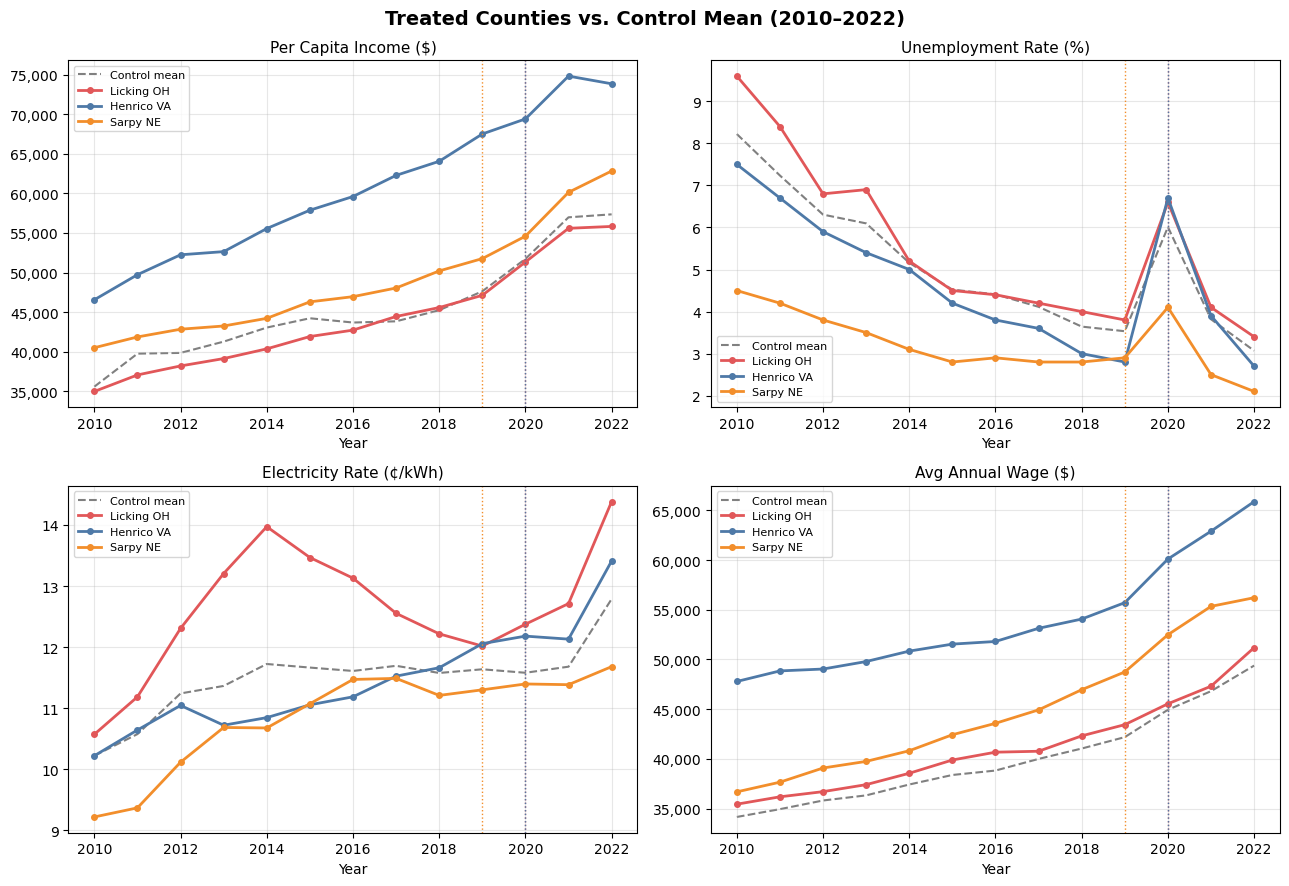

Dotted vertical lines = Meta opening year. Dashed grey = control group mean.


In [6]:
# Time series plots for treated counties vs control mean
outcome_vars = [
    ('per_capita_income',  'Per Capita Income ($)'),
    ('unemployment_rate',  'Unemployment Rate (%)'),
    ('elec_rate_cents_kwh','Electricity Rate (¢/kWh)'),
    ('avg_annual_wage',    'Avg Annual Wage ($)'),
]

treated_fips = {'39089': 'Licking OH', '51087': 'Henrico VA', '31153': 'Sarpy NE'}
colors       = {'39089': '#e15759', '51087': '#4e79a7', '31153': '#f28e2b'}
opening_year = {'39089': 2020, '51087': 2020, '31153': 2019}

control_mean = clean[clean.is_treated == 0].groupby('year')[list(dict(outcome_vars))].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Treated Counties vs. Control Mean (2010–2022)', fontsize=14, fontweight='bold')

for ax, (col, label) in zip(axes.flat, outcome_vars):
    ax.plot(control_mean.index, control_mean[col], color='grey', lw=1.5,
            linestyle='--', label='Control mean', zorder=1)
    for fips, name in treated_fips.items():
        ts = clean[clean.fips == fips].sort_values('year')
        ax.plot(ts.year, ts[col], color=colors[fips], lw=2, marker='o',
                markersize=4, label=name, zorder=2)
        ax.axvline(opening_year[fips], color=colors[fips], lw=1, linestyle=':')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/treated_vs_control_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dotted vertical lines = Meta opening year. Dashed grey = control group mean.')

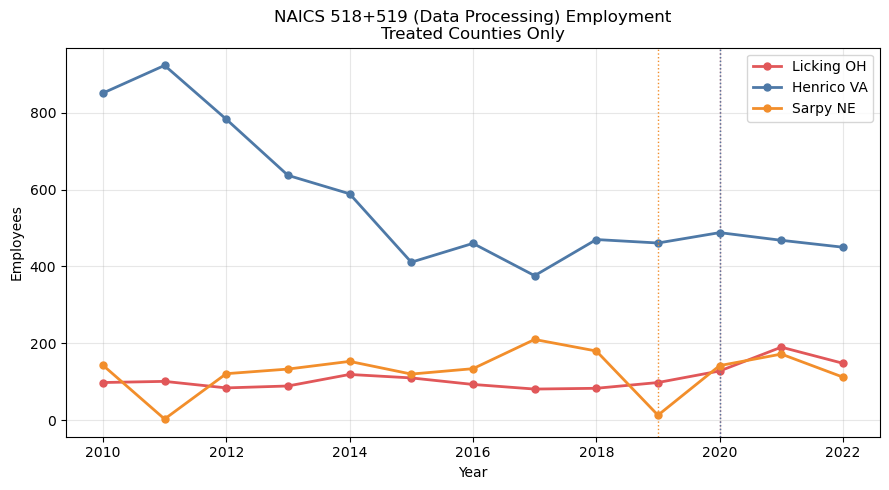

NaN values = suppressed by BLS (small cell counts). Dotted lines = opening year.


In [7]:
# Data processing employment — treated counties only (key outcome variable)
fig, ax = plt.subplots(figsize=(9, 5))

for fips, name in treated_fips.items():
    ts = clean[clean.fips == fips].sort_values('year')
    ax.plot(ts.year, ts['data_processing_employment'], color=colors[fips],
            lw=2, marker='o', markersize=5, label=name)
    ax.axvline(opening_year[fips], color=colors[fips], lw=1, linestyle=':')

ax.set_title('NAICS 518+519 (Data Processing) Employment\nTreated Counties Only', fontsize=12)
ax.set_xlabel('Year')
ax.set_ylabel('Employees')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('data/data_processing_employment.png', dpi=150, bbox_inches='tight')
plt.show()
print('NaN values = suppressed by BLS (small cell counts). Dotted lines = opening year.')

---
## Modeling Notes

### Before running regressions

1. **Drop structural NaN columns:**
   ```python
   df = df.drop(columns=['residential_sales_mwh', 'residential_customers'])
   ```

2. **Drop contaminated controls:**
   ```python
   df = df[df.contaminated_control == 0]
   ```

3. **Log-transform skewed variables** (right-skewed, large range):
   ```python
   for col in ['gdp_thousands', 'total_employment', 'labor_force', 'pop_density', 'total_wages']:
       df[f'log_{col}'] = np.log(df[col])
   ```

4. **Sarpy County compound treatment** (FIPS 31153): Google also opened in Sarpy County in 2019. Consider:
   - Running the main spec with all 3 treated counties, then a robustness check dropping Sarpy
   - Adding a Google indicator covariate

5. **Poverty rate 2010–2011:** Systemically missing for all counties. Either restrict pre-period to 2012+ or omit `poverty_rate` from specs using those years.

### Baseline DiD spec

```python
# Using linearmodels or statsmodels
# Y_it = α_i + γ_t + β·dc_active_it + X_it·δ + ε_it
# where α_i = county FE, γ_t = year FE
```

### Event study spec

```python
# Replace dc_active with year-relative dummies using years_since_dc
# Useful for checking parallel pre-trends and plotting dynamic effects
```